## **Exercise**
Complete the following tasks:
1. Load the [dataset](https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset) from Kaggle.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

file_path= r"D:\Second semester Data and Data Things\Data Engineering\online_retail_II.xlsx"
df = pd.read_excel(file_path)
print(df.head() )

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


2. Visualize the dataset and it's structure using appropriate libraries and plots.


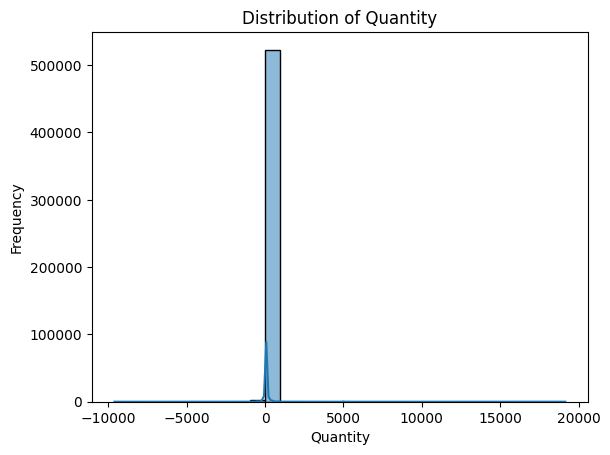

In [ ]:
sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title('Distribution of Quantity')   
plt.xlabel('Quantity')
plt.ylabel('Frequency') 
plt.show()

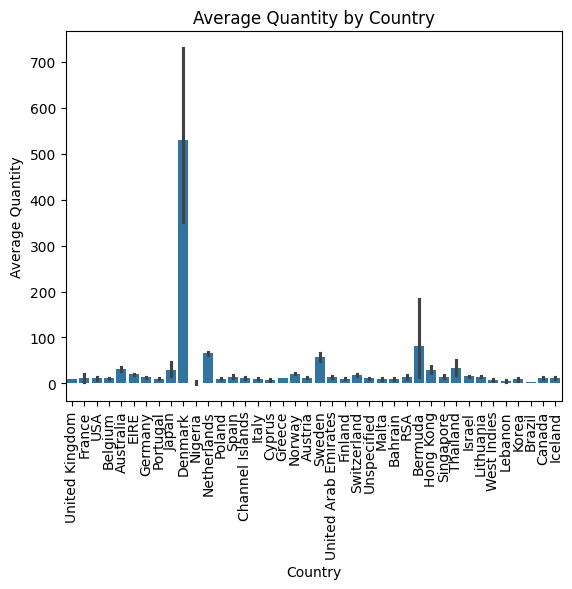

In [ ]:
sns.barplot(x='Country', y='Quantity', data=df)
plt.title('Average Quantity by Country')
plt.xlabel('Country')
plt.ylabel('Average Quantity')
plt.xticks(rotation=90)
plt.show()

3. Do some basic cleaning to handle missing values


In [ ]:
df.delete=df.copy()
print(df.delete.isnull().sum())

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_18908\4088616381.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.delete=df.copy()


In [ ]:
df_delete_cleaned=df.delete.dropna()
print(df_delete_cleaned.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [ ]:
df_replace=df.copy()
print(df_replace.isnull().sum())

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [ ]:
# Numeric columns
# df_replace['Price'] = df_replace['Price'].fillna(df_replace['Price'].median())

# Categorical columns
df_replace['Description'] = df_replace['Description'].fillna('Unknown Product')
# df_replace['Country'] = df_replace['Country'].fillna('Unknown')

# Customer ID (often missing)
df_replace['Customer ID'] = df_replace['Customer ID'].fillna(-1)
print(df_replace['Description'].isnull().sum())

0


4. Create the following features:
  *   Revenue
  *   DayOfWeek: to analyze sales trends by weekdays.
  *   TotalRevenue for each CustomerID
  *   Most popular product based on Revenue.
  *   Ordersize by summing Quantity for each InvoiceNo


In [ ]:
df["Revenue"] = df["Quantity"] * df["Price"]
print(df["Revenue"])

0          83.40
1          81.00
2          81.00
3         100.80
4          30.00
           ...  
525456      5.90
525457      3.75
525458      3.75
525459      7.50
525460      3.90
Name: Revenue, Length: 525461, dtype: float64


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
print(df["DayOfWeek"])

0          Tuesday
1          Tuesday
2          Tuesday
3          Tuesday
4          Tuesday
            ...   
525456    Thursday
525457    Thursday
525458    Thursday
525459    Thursday
525460    Thursday
Name: DayOfWeek, Length: 525461, dtype: str


In [ ]:
total_revenue_per_customer = (
    df.groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index(name="TotalRevenue")
)
print(total_revenue_per_customer.head())

   Customer ID  TotalRevenue
0      12346.0        -64.68
1      12347.0       1323.32
2      12348.0        222.16
3      12349.0       2646.99
4      12351.0        300.93


In [ ]:
product_revenue = (
    df.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values(by="Revenue", ascending=False)
)

most_popular_product = product_revenue.head(1)
print(most_popular_product)

     StockCode               Description    Revenue
1839     22423  REGENCY CAKESTAND 3 TIER  163051.46


In [ ]:
order_size = (
    df.groupby("Invoice")["Quantity"]
    .sum()
    .reset_index(name="OrderSize")
)
print(order_size.head())

  Invoice  OrderSize
0  489434        166
1  489435         60
2  489436        193
3  489437        145
4  489438        826


5. Apply a lambda function to:
  * Segment customers into tiers based on TotalRevenue (e.g., "High", "Medium", "Low").
  * Extract key information from Description and add them as columns (e.g., presence of specific keywords like "Gift" or "Discount"). At least one extra column should be added
  * Categorize transactions as "Small", "Medium", or "Large" based on Revenue.
  * **Detect Seasonal Items:** Flag items as "Christmas"-themed if the description contains relevant words.
  * Classify customers as "Loyal", "Occasional", or "One-time" based on the number of purchases.
  *  **Identify Multi-Item Invoices:** Flag invoices with multiple unique items as "Multi-Item Order".


In [ ]:
df = df.merge(
    df.groupby("Customer ID")["Revenue"].sum().reset_index(name="TotalRevenue"),
    on="Customer ID",
    how="left"
)
df["CustomerTier"] = df["Revenue"].apply(
    lambda x: "High" if x >= 5000 else "Medium" if x >= 2000 else "Low"
)
print(df["CustomerTier"].value_counts())

CustomerTier
Low       525365
Medium        76
High          20
Name: count, dtype: int64


In [ ]:
df["IsGift"] = df["Description"].apply(
    lambda x: 1 if isinstance(x, str) and "gift" in x.lower() else 0
)
df["IsDiscount"] = df["Description"].apply(
    lambda x: 1 if isinstance(x, str) and "discount" in x.lower() else 0
)
print(df[["IsGift", "IsDiscount"]].head())

   IsGift  IsDiscount
0       0           0
1       0           0
2       0           0
3       0           0
4       0           0


In [ ]:
df["TransactionSize"] = df["Revenue"].apply(
    lambda x: "Small" if x < 20 else "Medium" if x < 100 else "Large"
)
print(df["TransactionSize"].value_counts())

TransactionSize
Small     425752
Medium     86294
Large      13415
Name: count, dtype: int64


In [ ]:
df["IsChristmasItem"] = df["Description"].apply(
    lambda x: 1 if isinstance(x, str) and any(
        word in x.lower() for word in ["christmas", "xmas", "noel", "snow"]
    ) else 0
)
print(df["IsChristmasItem"].value_counts())

IsChristmasItem
0    504353
1     21108
Name: count, dtype: int64


In [ ]:
purchase_counts = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index(name="PurchaseCount")
)

df = df.merge(purchase_counts, on="Customer ID", how="left")
df["CustomerType"] = df["PurchaseCount"].apply(
    lambda x: "Loyal" if x >= 10 else "Occasional" if x >= 2 else "One-time"
)
print(df["CustomerType"].value_counts())

CustomerType
Loyal         196302
Occasional    194607
One-time      134552
Name: count, dtype: int64


In [ ]:
invoice_items = (
    df.groupby("Invoice")["StockCode"]
    .nunique()
    .reset_index(name="UniqueItems")
)

df = df.merge(invoice_items, on="Invoice", how="left")
df["OrderType"] = df["UniqueItems"].apply(
    lambda x: "Multi-Item Order" if x > 1 else "Single-Item Order"
)
print(df["OrderType"].value_counts())

OrderType
Multi-Item Order     517337
Single-Item Order      8124
Name: count, dtype: int64


7. Wrap all fo the above into an ETL pipeline.

In [ ]:
# Extracting data function
def extract_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    return df

# Transforming data function
def transform_data(df):
    # Convert date
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

    # ----------------------------
    # Revenue
    # ----------------------------
    df["Revenue"] = df["Quantity"] * df["Price"]

    # ----------------------------
    # Day of Week
    # ----------------------------
    df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

    # ----------------------------
    # Total Revenue per Customer
    # ----------------------------
    total_revenue = (
        df.groupby("Customer ID")["Revenue"]
        .sum()
        .reset_index(name="TotalRevenue")
    )
    df = df.merge(total_revenue, on="Customer ID", how="left")

    # ----------------------------
    # Customer Tier
    # ----------------------------
    df["CustomerTier"] = df["TotalRevenue"].apply(
        lambda x: "High" if x >= 5000 else "Medium" if x >= 2000 else "Low"
    )

    # ----------------------------
    # Description-based features
    # ----------------------------
    df["IsGift"] = df["Description"].apply(
        lambda x: 1 if isinstance(x, str) and "gift" in x.lower() else 0
    )

    df["IsDiscount"] = df["Description"].apply(
        lambda x: 1 if isinstance(x, str) and "discount" in x.lower() else 0
    )

    df["IsChristmasItem"] = df["Description"].apply(
        lambda x: 1 if isinstance(x, str) and any(
            word in x.lower() for word in ["christmas", "xmas", "noel", "snow"]
        ) else 0
    )

    # ----------------------------
    # Transaction Size
    # ----------------------------
    df["TransactionSize"] = df["Revenue"].apply(
        lambda x: "Small" if x < 20 else "Medium" if x < 100 else "Large"
    )

    # ----------------------------
    # Customer Type (Loyalty)
    # ----------------------------
    purchase_counts = (
        df.groupby("Customer ID")["Invoice"]
        .nunique()
        .reset_index(name="PurchaseCount")
    )
    df = df.merge(purchase_counts, on="Customer ID", how="left")

    df["CustomerType"] = df["PurchaseCount"].apply(
        lambda x: "Loyal" if x >= 10 else "Occasional" if x >= 2 else "One-time"
    )

    # ----------------------------
    # Order Type (Multi-item)
    # ----------------------------
    invoice_items = (
        df.groupby("Invoice")["StockCode"]
        .nunique()
        .reset_index(name="UniqueItems")
    )
    df = df.merge(invoice_items, on="Invoice", how="left")

    df["OrderType"] = df["UniqueItems"].apply(
        lambda x: "Multi-Item Order" if x > 1 else "Single-Item Order"
    )

    return df

# Loading data function
def load_data(df, output_path):
    df.to_csv(output_path, index=False)
    print("ETL Pipeline completed successfully.")


# ETL Pipeline function
def run_etl_pipeline(input_path, output_path):
    df_raw = extract_data(input_path)
    df_transformed = transform_data(df_raw)
    load_data(df_transformed, output_path)

# Run the ETL pipeline
run_etl_pipeline(
    "online_retail_II.csv",
    "online_retail_transformed.csv"
)

ETL Pipeline completed successfully.


Extra tasks for practicing GroupBy
1. Join CustomerID with TotalRevenue to create Customer_Revenue column

In [ ]:
customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index(name="Customer_Revenue")
)

df = df.merge(customer_revenue, on="Customer ID", how="left")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,DayOfWeek,...,CustomerTier,IsGift,IsDiscount,TransactionSize,IsChristmasItem,PurchaseCount,CustomerType,UniqueItems,OrderType,Customer_Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,Tuesday,...,Low,0,0,Medium,1,7.0,Occasional,8,Multi-Item Order,1187.08
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,Tuesday,...,Low,0,0,Medium,0,7.0,Occasional,8,Multi-Item Order,1187.08
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,Tuesday,...,Low,0,0,Medium,0,7.0,Occasional,8,Multi-Item Order,1187.08
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,Tuesday,...,Low,0,0,Large,0,7.0,Occasional,8,Multi-Item Order,1187.08
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,Tuesday,...,Low,0,0,Medium,0,7.0,Occasional,8,Multi-Item Order,1187.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90,Thursday,...,Low,0,0,Small,0,4.0,Occasional,65,Multi-Item Order,755.56
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,Thursday,...,Low,0,0,Small,0,4.0,Occasional,65,Multi-Item Order,755.56
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,Thursday,...,Low,0,0,Small,0,4.0,Occasional,65,Multi-Item Order,755.56
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50,Thursday,...,Low,0,0,Small,0,4.0,Occasional,65,Multi-Item Order,755.56


2. Group by Country to find total revenue, total customers, and average order size per country.


In [ ]:
country_summary = (
    df.groupby("Country")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalCustomers=("Customer ID", "nunique"),
        AvgOrderSize=("Quantity", "mean")
    )
    .reset_index()
)
country_summary

,Country,TotalRevenue,TotalCustomers,AvgOrderSize
0,Australia,30051.800,15,30.662080
1,Austria,13023.280,10,12.065177
2,Bahrain,2313.150,2,9.485981
3,Belgium,22663.530,17,11.366224
4,Bermuda,1253.140,0,82.294118
5,Brazil,268.270,1,3.048387
6,Canada,1216.660,1,11.610390
7,Channel Islands,21367.320,12,12.134658
8,Cyprus,11216.450,7,7.889892
9,Denmark,46972.950,9,530.443925


3. Group by StockCode to find top-selling products by quantity.


In [ ]:
top_products = (
    df.groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .reset_index()
    .sort_values(by="Quantity", ascending=False)
)
top_products

,StockCode,Description,Quantity
4601,85123A,WHITE HANGING HEART T-LIGHT HOLDER,57428
2906,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54698
55,17003,BROCADE RING PURSE,47647
572,21212,PACK OF 72 RETRO SPOT CAKE CASES,46106
3092,84879,ASSORTED COLOUR BIRD ORNAMENT,44925
...,...,...,...
46,16235,?,-9000
4,10120,Zebra invcing error,-9000
273,20852,given away,-10000
1465,22126,given away,-10000


4. Group by CustomerID to calculate the average order value or frequency of purchases.

In [ ]:
invoice_revenue = (
    df.groupby(["Customer ID", "Invoice"])["Revenue"]
    .sum()
    .reset_index()
)

avg_order_value = (
    invoice_revenue.groupby("Customer ID")["Revenue"]
    .mean()
    .reset_index(name="AvgOrderValue")
)

purchase_frequency = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index(name="PurchaseFrequency")
)
invoice_revenue, avg_order_value, purchase_frequency

(       Customer ID  Invoice  Revenue
 0          12346.0   491725    45.00
 1          12346.0   491742    22.50
 2          12346.0   491744    22.50
 3          12346.0   492718    22.50
 4          12346.0   492722     1.00
 ...            ...      ...      ...
 23582      18287.0   508581  1071.61
 23583      18287.0   523289   862.00
 23584      18287.0   523290    30.60
 23585      18287.0   534346   381.50
 23586      18287.0  C489592    -5.10
 
 [23587 rows x 3 columns],
       Customer ID  AvgOrderValue
 0         12346.0      -4.312000
 1         12347.0     661.660000
 2         12348.0     222.160000
 3         12349.0     661.747500
 4         12351.0     300.930000
 ...           ...            ...
 4378      18283.0     106.961667
 4379      18284.0     218.340000
 4380      18285.0     427.000000
 4381      18286.0     396.143333
 4382      18287.0     468.122000
 
 [4383 rows x 2 columns],
       Customer ID  PurchaseFrequency
 0         12346.0                 15
 1 